# Predicting Stellar Class — Preprocessing & EDA

Kaggle Playground Series S6E6. Multiclass classification: `GALAXY` / `STAR` / `QSO`.
Metric — **balanced accuracy** (mean per-class recall), so class imbalance matters.

Notebook goals:
1. Load and validate the data (shapes, dtypes, missing values, duplicates, train/test consistency).
2. Full EDA: target variable, numeric and categorical features, relation to the class, correlations, anomalies.
3. Build a clean feature set for modeling and persist it.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)

PURPLE_BLUE = ['#3B2F8F', '#6A5ACD', '#9D7BE0', '#4169E1', '#7B68EE', '#5B8DEF']
CLASS_PALETTE = {'GALAXY': '#3B2F8F', 'QSO': '#6A5ACD', 'STAR': '#9D7BE0'}
SEQ_CMAP = 'BuPu'

sns.set_theme(style='whitegrid', palette=PURPLE_BLUE)
plt.rcParams['figure.dpi'] = 110

ON_KAGGLE = Path('/kaggle/input').exists()
if ON_KAGGLE:
    train_paths = sorted(Path('/kaggle/input').rglob('train.csv'))
    DATA_DIR = train_paths[0].parent
    OUT_DIR = Path('/kaggle/working')
else:
    DATA_DIR = Path('../docs/dataset')
    OUT_DIR = Path('../data_processed')
print('Environment:', 'Kaggle' if ON_KAGGLE else 'local')
print('DATA_DIR:', DATA_DIR)
print('OUT_DIR :', OUT_DIR)

TARGET = 'class'
ID = 'id'
CLASSES = ['GALAXY', 'QSO', 'STAR']

_TABLE_STYLES = [
    {'selector': 'caption', 'props': [('caption-side', 'top'), ('font-size', '13px'),
                                      ('font-weight', '700'), ('color', '#3B2F8F'),
                                      ('text-align', 'left'), ('padding', '4px 2px 8px')]},
    {'selector': 'th', 'props': [('background-color', '#EDE7F6'), ('color', '#3B2F8F'),
                                 ('font-weight', '600'), ('text-align', 'center'),
                                 ('border', 'none'), ('padding', '5px 10px')]},
    {'selector': 'td', 'props': [('text-align', 'center'), ('padding', '4px 10px')]},
    {'selector': 'tr:hover td', 'props': [('background-color', '#F3F0FA')]},
]

def styled(df, caption='', gradient=False, axis=0, precision=3):
    s = (df.style
         .format(precision=precision)
         .set_caption(caption)
         .set_table_styles(_TABLE_STYLES))
    if gradient:
        num = df.select_dtypes('number').columns
        s = s.background_gradient(cmap=SEQ_CMAP, subset=list(num), axis=axis)
    return s

def reduce_mem(df):
    for col in df.select_dtypes('float64').columns:
        df[col] = df[col].astype('float32')
    for col in df.select_dtypes('int64').columns:
        df[col] = pd.to_numeric(df[col], downcast='integer')
    return df

Environment: local
DATA_DIR: ../docs/dataset
OUT_DIR : ../data_processed


## 1. Data loading

In [2]:
train = reduce_mem(pd.read_csv(DATA_DIR / 'train.csv'))
test = reduce_mem(pd.read_csv(DATA_DIR / 'test.csv'))
sample_sub = pd.read_csv(DATA_DIR / 'sample_submission.csv')

print('train:', train.shape)
print('test :', test.shape)
print('sub  :', sample_sub.shape)
print('train memory: %.1f MB' % (train.memory_usage(deep=True).sum() / 1024**2))
train.head()

train: (577347, 12)
test : (247435, 11)
sub  : (247435, 2)
train memory: 124.0 MB


,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734253,16.959272,25.472122,21.895559,20.357925,19.257113,18.621058,0.408982,M,Red_Sequence,GALAXY
1,1,127.988678,32.346718,20.778509,19.087063,17.587208,17.226067,16.786432,0.157976,M,Red_Sequence,GALAXY
2,2,179.792648,35.344845,21.035202,21.079128,21.171841,20.582630,20.557365,2.823770,O/B,Blue_Cloud,QSO
3,3,225.818298,48.569420,23.305056,21.050735,19.017754,18.365658,17.914951,0.536099,M,Red_Sequence,GALAXY
4,4,141.836136,19.342852,21.703157,19.471680,18.234449,17.899446,17.616184,0.555761,M,Red_Sequence,GALAXY


**Observations.** Train has ~577k rows and 12 columns; test has ~247k rows and 11 columns (no `class`). The feature schema matches between train and test, and `sample_submission` aligns with the test size, so the split is well formed.

## 2. Basic data quality checks

In [3]:
schema = pd.DataFrame({
    'dtype': train.dtypes.astype(str),
    'non_null': train.notna().sum().values,
    'nulls': train.isnull().sum().values,
    'n_unique': train.nunique().values,
})
schema['%missing'] = (schema['nulls'] / len(train) * 100).round(2)
styled(schema, caption='Train schema overview — %d rows x %d cols' % train.shape, precision=2)

,dtype,non_null,nulls,n_unique,%missing
id,int32,577347,0,577347,0.00
alpha,float32,577347,0,270395,0.00
delta,float32,577347,0,277628,0.00
u,float32,577347,0,535340,0.00
g,float32,577347,0,523249,0.00
r,float32,577347,0,518510,0.00
i,float32,577347,0,520338,0.00
z,float32,577347,0,521317,0.00
redshift,float32,577347,0,570459,0.00
spectral_type,object,577347,0,4,0.00


**Observations.** 8 numeric columns (`float64`), 1 integer `id`, and 3 `object` columns (`spectral_type`, `galaxy_population`, `class`). Every column is fully populated (577,347 non-null), confirming no missing data in train at the dtype level.

In [4]:
miss = pd.DataFrame({
    'train_nulls': train.isnull().sum(),
    'test_nulls': test.reindex(columns=train.columns).isnull().sum(),
})
print('Total nulls  train:', int(train.isnull().sum().sum()),
      '| test:', int(test.isnull().sum().sum()))
styled(miss, caption='Missing values by column', precision=0)

Total nulls  train: 0 | test: 0


,train_nulls,test_nulls
id,0,0
alpha,0,0
delta,0,0
u,0,0
g,0,0
r,0,0
i,0,0
z,0,0
redshift,0,0
spectral_type,0,0


**Observations.** No missing values anywhere except `class` in test, which is expected since the target is what we predict. No imputation strategy is required.

In [5]:
feat_cols = [c for c in train.columns if c not in (ID, TARGET)]
checks = pd.DataFrame({
    'value': [
        train[ID].duplicated().sum(),
        test[ID].duplicated().sum(),
        len(set(train[ID]) & set(test[ID])),
        len((set(train.columns) - {TARGET}) - set(test.columns)),
        len(set(test.columns) - (set(train.columns) - {TARGET})),
        train.duplicated(subset=feat_cols).sum(),
    ]},
    index=['Duplicate ids (train)', 'Duplicate ids (test)', 'Shared ids train/test',
           'Columns only in train (excl. class)', 'Columns only in test',
           'Fully duplicated feature rows (train)'])
checks.index.name = 'check'
styled(checks, caption='Consistency & leakage checks', precision=0)

,value
check,
Duplicate ids (train),0
Duplicate ids (test),0
Shared ids train/test,0
Columns only in train (excl. class),0
Columns only in test,0
Fully duplicated feature rows (train),0


**Observations.** No duplicate `id` in either split, no overlap of ids between train and test, and no fully duplicated feature rows. The feature columns are identical across splits (only `class` is train-exclusive), so the data is consistent and leak-free.

In [6]:
# Cross-split leakage: do any full feature vectors appear in BOTH train and test?
overlap = train.merge(test[feat_cols].drop_duplicates(), on=feat_cols, how='inner')
print('Train rows whose full feature vector also appears in test:', len(overlap))
print('  as share of test rows:', f'{len(overlap) / len(test):.4%}')

Train rows whose full feature vector also appears in test: 0
  as share of test rows: 0.0000%


**Observations.** **0** train rows share a full feature vector with any test row — no cross-split leakage and no accidental row reuse from the synthetic generation. Safe to validate on train CV without worrying about test contamination.

In [7]:
num_cols = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']
cat_cols = ['spectral_type', 'galaxy_population']
print('Numeric    :', num_cols)
print('Categorical:', cat_cols)
styled(train[num_cols].describe().T, caption='Numeric feature summary (train)',
       gradient=True, axis=0)

Numeric    : ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']
Categorical: ['spectral_type', 'galaxy_population']


,count,mean,std,min,25%,50%,75%,max
alpha,577347.000,181.617,96.243,0.012,132.161,188.681,231.830,360.000
delta,577347.000,21.835,18.934,-17.967,2.474,21.484,36.988,79.158
u,577347.000,22.442,2.018,-0.139,20.977,22.570,23.869,28.253
g,577347.000,21.007,1.795,13.535,19.865,21.468,22.293,27.620
r,577347.000,19.963,1.649,12.579,18.821,20.431,21.164,25.254
i,577347.000,19.379,1.580,11.963,18.307,19.632,20.608,27.911
z,577347.000,19.041,1.584,11.683,17.973,19.189,20.162,26.827
redshift,577347.000,0.723,0.810,-0.010,0.181,0.498,0.881,7.011


**Observations.** The five photometric magnitudes (`u, g, r, i, z`) sit in a similar 12–28 range, hinting at strong correlation among them. `redshift` is heavily right-skewed (mean 0.72, max 7.0) with a small negative minimum. `alpha` spans the full 0–360° RA range and `delta` the declination range, as expected for sky coordinates.

## 3. Target variable

,count,share
class,,
GALAXY,377480,0.654
QSO,117143,0.203
STAR,82724,0.143


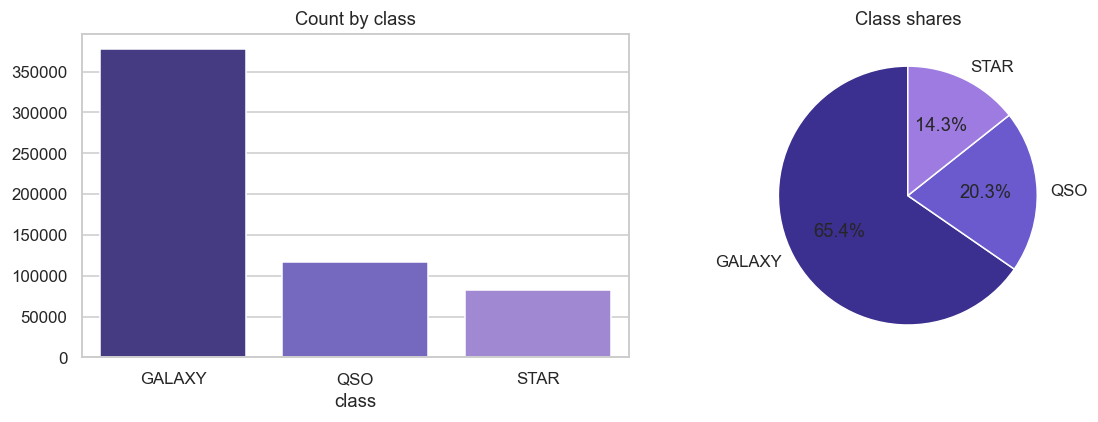

In [8]:
vc = train[TARGET].value_counts()
vc_norm = train[TARGET].value_counts(normalize=True)
target_tbl = pd.DataFrame({'count': vc, 'share': vc_norm.round(4)})
display(styled(target_tbl, caption='Target class balance', gradient=True, axis=0))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.barplot(x=vc.index, y=vc.values, ax=ax[0],
            hue=vc.index, legend=False,
            palette=[CLASS_PALETTE.get(c, '#6A5ACD') for c in vc.index])
ax[0].set_title('Count by class')
ax[1].pie(vc.values, labels=vc.index, autopct='%1.1f%%', startangle=90,
          colors=[CLASS_PALETTE.get(c, '#6A5ACD') for c in vc.index])
ax[1].set_title('Class shares')
plt.tight_layout(); plt.show()

**Observations.** The target is clearly imbalanced: GALAXY dominates (~65%), QSO is mid-sized (~20%), and STAR is the minority (~14%). Because the metric is balanced accuracy, the minority STAR class must be protected — use `StratifiedKFold` and `balanced_accuracy_score`, and consider class weighting.

## 4. Numeric features: distributions

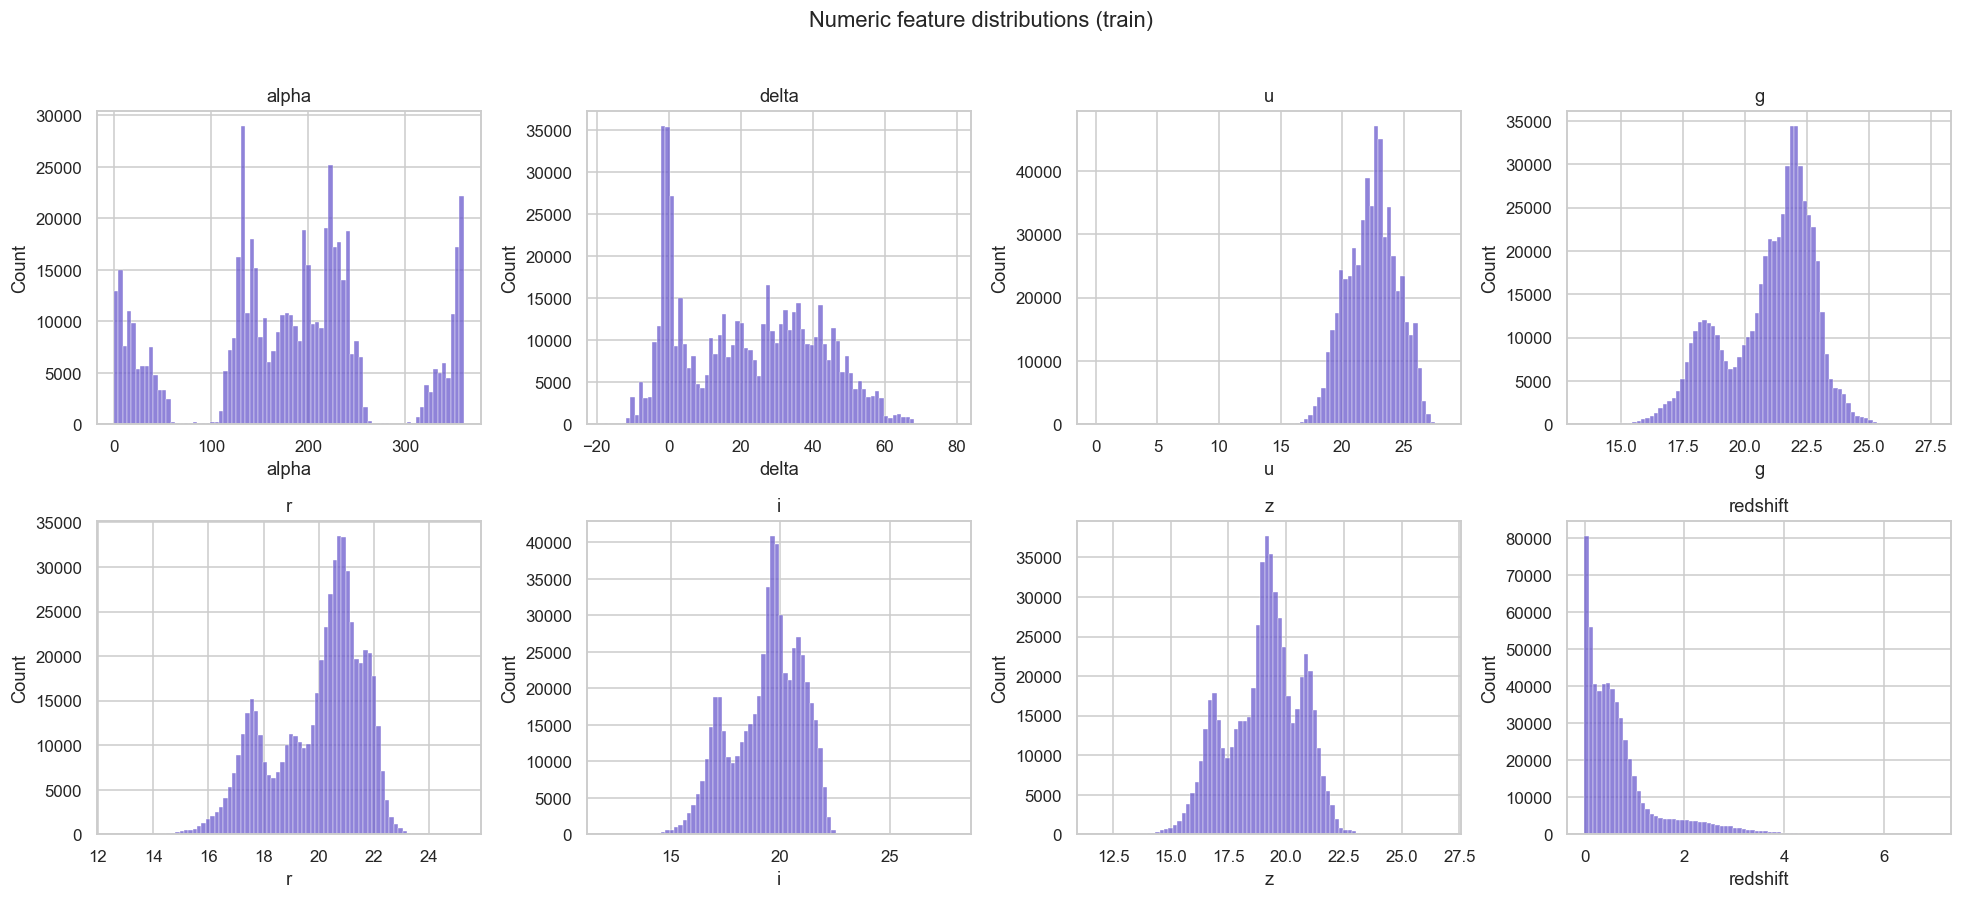

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.ravel(), num_cols):
    sns.histplot(train[col], bins=80, ax=ax, color='#6A5ACD')
    ax.set_title(col)
plt.suptitle('Numeric feature distributions (train)', y=1.02)
plt.tight_layout(); plt.show()

**Observations.** The magnitudes are roughly bell-shaped with mild left skew. `redshift` is strongly right-skewed with a spike near zero (stars) and a long tail (quasars) — this multimodality already foreshadows its discriminative power. `alpha`/`delta` are broad and fairly flat, typical of survey footprint coverage.

In [10]:
for col in num_cols:
    neg = (train[col] < 0).sum()
    print(f'{col:9s}  min={train[col].min():10.4f}  max={train[col].max():10.4f}  <0: {neg}')

alpha      min=    0.0117  max=  359.9998  <0: 0
delta      min=  -17.9670  max=   79.1583  <0: 103585
u          min=   -0.1392  max=   28.2533  <0: 1
g          min=   13.5355  max=   27.6202  <0: 0
r          min=   12.5794  max=   25.2545  <0: 0
i          min=   11.9628  max=   27.9109  <0: 0
z          min=   11.6828  max=   26.8269  <0: 0
redshift   min=   -0.0100  max=    7.0108  <0: 8957


**Observations.** Negative `delta` values (~103k) are just southern-hemisphere declinations and are valid. Negative `redshift` (~9k) is physically plausible (peculiar velocities / measurement noise) and should be kept. Only a single negative `u` magnitude appears — a likely outlier, but not worth special handling given its rarity.

In [11]:
SENTINELS = [-9999, -999, 9999, 99, -99]

def sentinel_report(df, name):
    print(f'=== {name} ===')
    for col in num_cols:
        s = df[col]
        sent = s.isin(SENTINELS).sum()
        extreme = ((s < -50) | (s > 100)).sum()
        print(f'{col:9s} sentinel={sent:>6d}  extreme(<-50|>100)={extreme:>6d}'
              f'  min={s.min():9.3f}  max={s.max():9.3f}')

sentinel_report(train, 'train')
print()
sentinel_report(test, 'test')

=== train ===
alpha     sentinel=     0  extreme(<-50|>100)=481809  min=    0.012  max=  360.000
delta     sentinel=     0  extreme(<-50|>100)=     0  min=  -17.967  max=   79.158
u         sentinel=     0  extreme(<-50|>100)=     0  min=   -0.139  max=   28.253
g         sentinel=     0  extreme(<-50|>100)=     0  min=   13.535  max=   27.620
r         sentinel=     0  extreme(<-50|>100)=     0  min=   12.579  max=   25.254
i         sentinel=     0  extreme(<-50|>100)=     0  min=   11.963  max=   27.911
z         sentinel=     0  extreme(<-50|>100)=     0  min=   11.683  max=   26.827
redshift  sentinel=     0  extreme(<-50|>100)=     0  min=   -0.010  max=    7.011

=== test ===
alpha     sentinel=     0  extreme(<-50|>100)=206338  min=    0.011  max=  360.000
delta     sentinel=     0  extreme(<-50|>100)=     0  min=  -17.959  max=   79.170
u         sentinel=     0  extreme(<-50|>100)=     0  min=   13.903  max=   27.836


g         sentinel=     0  extreme(<-50|>100)=     0  min=   13.375  max=   27.173
r         sentinel=     0  extreme(<-50|>100)=     0  min=   10.391  max=   25.292
i         sentinel=     0  extreme(<-50|>100)=     0  min=   10.034  max=   24.568


z         sentinel=     0  extreme(<-50|>100)=     0  min=   10.632  max=   25.700
redshift  sentinel=     0  extreme(<-50|>100)=     0  min=   -0.010  max=    7.007


**Observations.** No placeholder sentinels (`-9999` / `-999` / `9999` …) anywhere in train or test, and the photometric magnitudes (`u, g, r, i, z`) all sit in a sane ~10–28 range with no extreme values. The only "extreme" hits are on `alpha`, which is simply right ascension above 100° (valid for a 0–360° range), not a data problem. This matters before mixing in external SDSS data, where `-9999` "no measurement" codes are common: the competition data is clean, so any sentinels later would come from the external set and must be filtered.

## 5. Numeric features by class

,count,mean,std,min,25%,50%,75%,max
class,,,,,,,,
GALAXY,377480.000,0.509,0.309,-0.010,0.267,0.482,0.715,6.860
QSO,117143.000,1.876,1.070,0.000,1.132,1.799,2.506,7.011
STAR,82724.000,0.068,0.064,-0.010,0.022,0.056,0.102,5.445


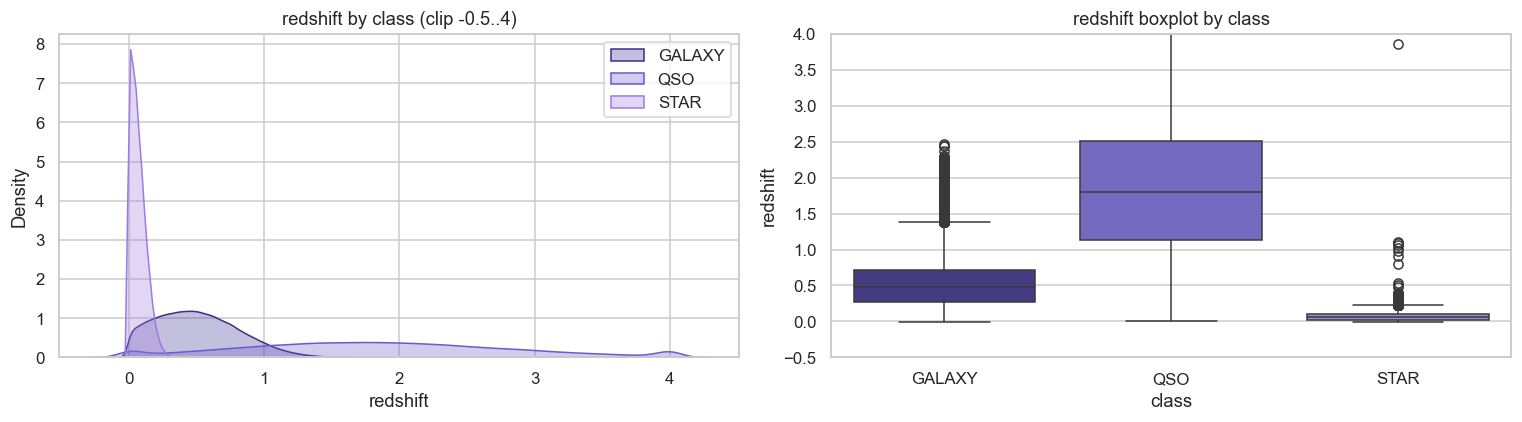

In [12]:
display(styled(train.groupby(TARGET)['redshift'].describe().round(3),
               caption='redshift by class', gradient=True, axis=0))

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
for cls in CLASSES:
    sns.kdeplot(train.loc[train[TARGET] == cls, 'redshift'].clip(-0.5, 4),
                label=cls, ax=ax[0], fill=True, alpha=0.3, color=CLASS_PALETTE[cls])
ax[0].set_title('redshift by class (clip -0.5..4)'); ax[0].legend()
sns.boxplot(data=train, x=TARGET, y='redshift', order=CLASSES, ax=ax[1],
            hue=TARGET, legend=False,
            palette=[CLASS_PALETTE[c] for c in CLASSES])
ax[1].set_ylim(-0.5, 4); ax[1].set_title('redshift boxplot by class')
plt.tight_layout(); plt.show()

**Observations.** `redshift` separates the classes almost perfectly: STAR clusters at ≈ 0, GALAXY occupies a moderate range, and QSO sits at high redshift. This is the single most powerful predictor and should drive most of the model's accuracy.

In [13]:
star = train[train[TARGET] == 'STAR']
print('STAR rows:', len(star), '| redshift max:', round(star['redshift'].max(), 3))
for thr in [0.01, 0.05, 0.1, 0.5, 1.0]:
    n = (star['redshift'] > thr).sum()
    print(f'  STAR with redshift > {thr:<4}: {n:>6d}  ({n / len(star):.1%})')

hi = star[star['redshift'] > 0.1]
print('\nHigh-z STAR (redshift > 0.1) by spectral_type:')
print(hi['spectral_type'].value_counts())
print('\nClass redshift spread (q01 / median / q99):')
print(train.groupby(TARGET)['redshift']
      .quantile([0.01, 0.5, 0.99]).unstack().loc[CLASSES].round(4))

STAR rows: 82724 | redshift max: 5.445
  STAR with redshift > 0.01:  69664  (84.2%)
  STAR with redshift > 0.05:  45010  (54.4%)
  STAR with redshift > 0.1 :  21448  (25.9%)
  STAR with redshift > 0.5 :     12  (0.0%)
  STAR with redshift > 1.0 :      7  (0.0%)

High-z STAR (redshift > 0.1) by spectral_type:
spectral_type
A/F    9437
G/K    6774
M      2920
O/B    2317
Name: count, dtype: int64

Class redshift spread (q01 / median / q99):
          0.01    0.50    0.99
class                         
GALAXY  0.0052  0.4820  1.3081
QSO     0.0001  1.7989  5.1615
STAR   -0.0087  0.0565  0.2378


**Observations.** The "stars at impossible redshift" are largely a framing issue: only **12** STAR rows exceed `redshift` 0.5 (max ≈ 5.4), so the truly non-physical tail is tiny. The real structure is subtler — STAR has a non-trivial *moderate* spread (median ≈ 0.057, q99 ≈ 0.24), not a tight spike at zero, and that spread **overlaps the low-redshift end of GALAXY** (GALAXY q01 ≈ 0.005). High-z STAR objects span all spectral types and lean `Blue_Cloud`. Takeaways: (1) the handful of `redshift > 0.5` STARs are worth an explicit flag but won't move the score much; (2) the STAR↔GALAXY confusion in the `redshift` 0.01–0.25 band is the actual battleground, and (3) the earlier "STAR clusters tightly at ≈0" reading should be softened to "STAR is low but with a real moderate tail".

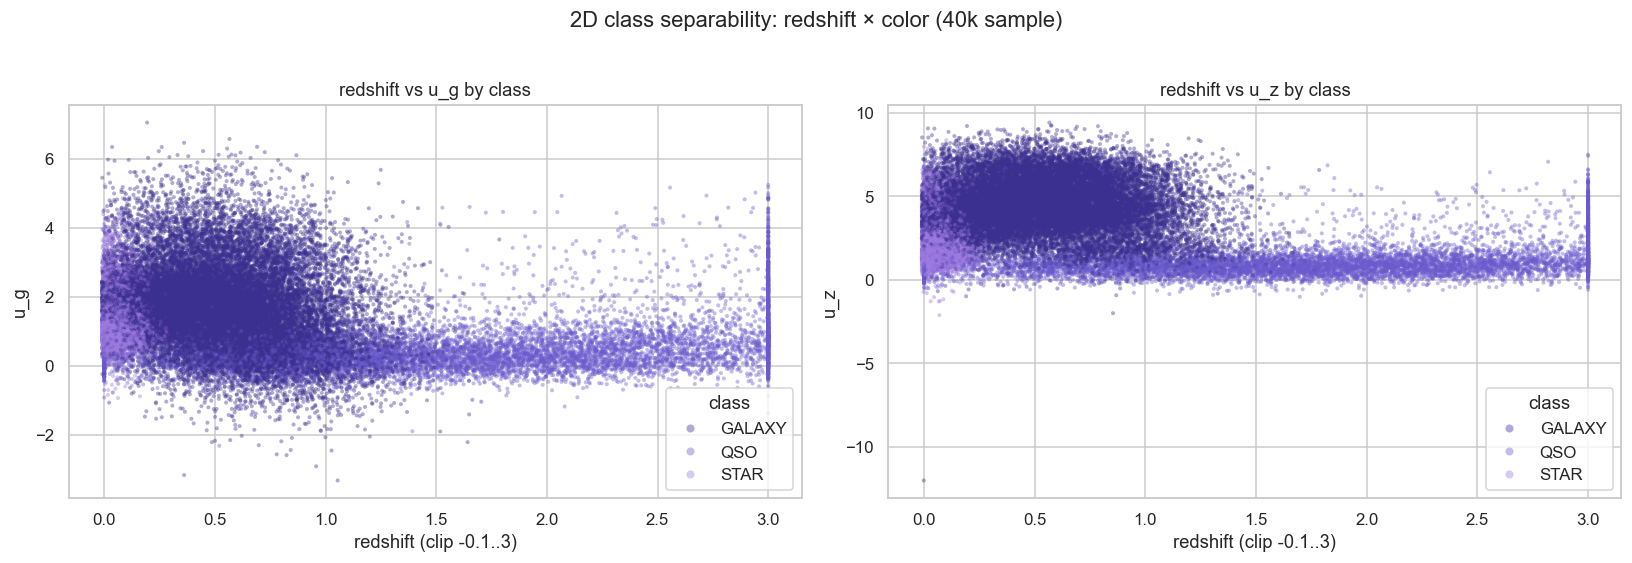

In [14]:
samp = train.sample(40000, random_state=42).copy()
samp['u_g'] = samp['u'] - samp['g']
samp['u_z'] = samp['u'] - samp['z']

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
for a, ycol in zip(ax, ['u_g', 'u_z']):
    sns.scatterplot(data=samp, x=samp['redshift'].clip(-0.1, 3), y=ycol,
                    hue=TARGET, hue_order=CLASSES, palette=CLASS_PALETTE,
                    s=7, alpha=0.4, linewidth=0, ax=a)
    a.set_xlabel('redshift (clip -0.1..3)')
    a.set_title(f'redshift vs {ycol} by class')
    a.legend(title='class', markerscale=2)
plt.suptitle('2D class separability: redshift × color (40k sample)', y=1.02)
plt.tight_layout(); plt.show()

**Observations.** In the `redshift` × `u−g` plane the classes form three bands: STAR low and tight, GALAXY in the middle, QSO high — but STAR and GALAXY clearly **share the low-redshift strip** (roughly `redshift` 0.01–0.25), and color alone does not fully separate them there. This is the concrete confusion zone behind the STAR recall bottleneck: features that sharpen the STAR↔GALAXY boundary in this strip (e.g. redshift bins, `z`-anomaly flags, color interactions) are where balanced accuracy will be won.

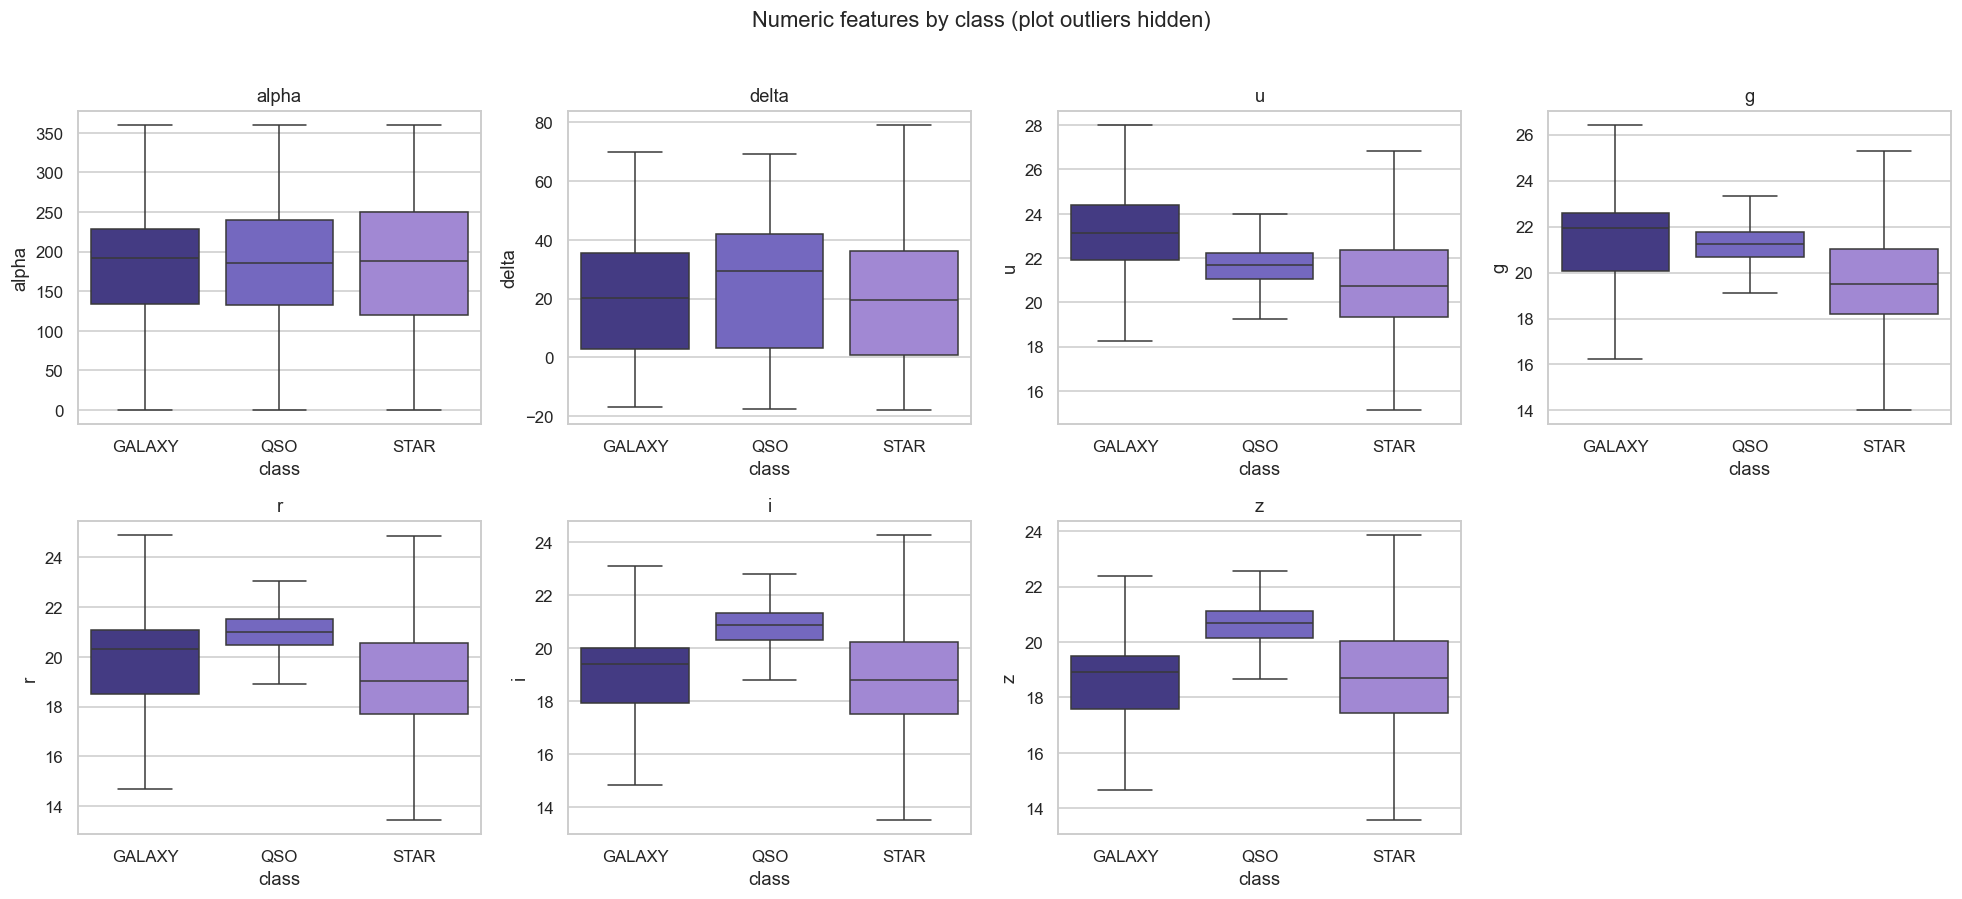

In [15]:
other_num = [c for c in num_cols if c != 'redshift']
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.ravel(), other_num):
    sns.boxplot(data=train, x=TARGET, y=col, order=CLASSES, ax=ax, showfliers=False,
                hue=TARGET, legend=False,
                palette=[CLASS_PALETTE[c] for c in CLASSES])
    ax.set_title(col)
for ax in axes.ravel()[len(other_num):]:
    ax.axis('off')
plt.suptitle('Numeric features by class (plot outliers hidden)', y=1.02)
plt.tight_layout(); plt.show()

**Observations.** The raw magnitudes overlap heavily across classes — individually they are weak separators. The class medians differ only modestly, which reinforces that derived colors (band differences) should be more informative than the magnitudes themselves.

## 6. Categorical features

In [16]:
for col in cat_cols:
    print(f'=== {col} ===')
    print(train[col].value_counts())
    print('unique in test but missing from train:', set(test[col].unique()) - set(train[col].unique()))
    print()

=== spectral_type ===
spectral_type
M      303323
A/F    122122
G/K    108546
O/B     43356
Name: count, dtype: int64
unique in test but missing from train: set()

=== galaxy_population ===
galaxy_population
Red_Sequence    319565
Blue_Cloud      257782
Name: count, dtype: int64
unique in test but missing from train: set()



**Observations.** `spectral_type` has 4 levels (M most common, O/B rarest) and `galaxy_population` is binary. No unseen categories appear in test, so a simple ordinal/category encoding is safe with no fallback needed for unknown values.

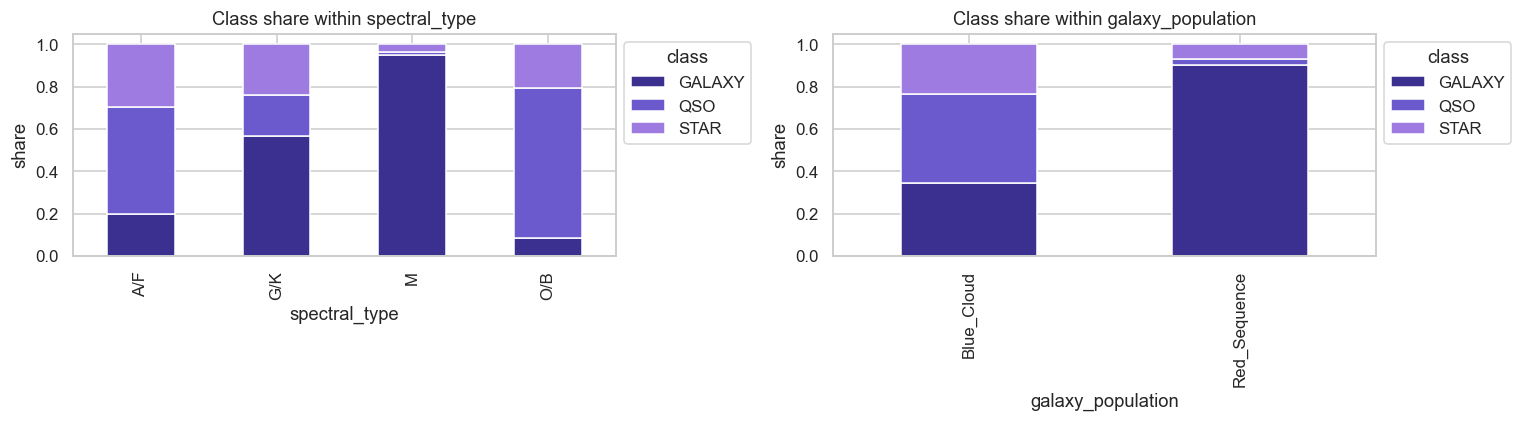

class          GALAXY    QSO   STAR
spectral_type                      
A/F             0.198  0.504  0.298
G/K             0.568  0.193  0.240
M               0.950  0.013  0.038
O/B             0.083  0.711  0.206


In [17]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
for a, col in zip(ax, cat_cols):
    ct = pd.crosstab(train[col], train[TARGET], normalize='index')[CLASSES]
    ct.plot(kind='bar', stacked=True, ax=a, color=[CLASS_PALETTE[c] for c in CLASSES])
    a.set_title(f'Class share within {col}'); a.set_ylabel('share')
    a.legend(title='class', bbox_to_anchor=(1.0, 1.0))
plt.tight_layout(); plt.show()

print(pd.crosstab(train['spectral_type'], train[TARGET], normalize='index').round(3))

**Observations.** Class composition shifts strongly with `spectral_type`: the O/B (hot) type is dominated by QSO, while cooler types lean toward GALAXY/STAR. `galaxy_population` also splits the classes meaningfully. Both categoricals carry real signal and should be kept as features.

## 7. Correlations and spatial distribution

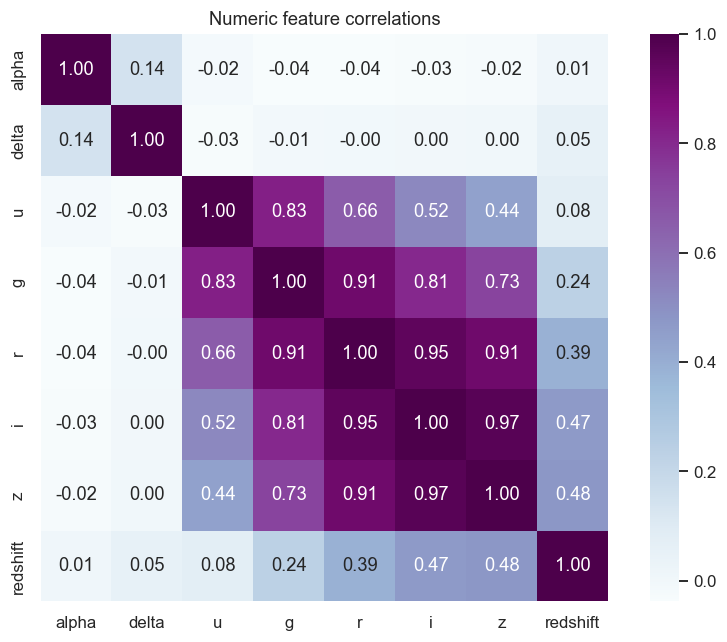

In [18]:
corr = train[num_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap=SEQ_CMAP, square=True)
plt.title('Numeric feature correlations')
plt.tight_layout(); plt.show()

**Observations.** The `u, g, r, i, z` bands are very highly correlated with one another (multicollinearity), confirming the earlier hypothesis. Color differences (`u-g`, `g-r`, …) decorrelate this block and are expected to be more informative than the raw magnitudes.

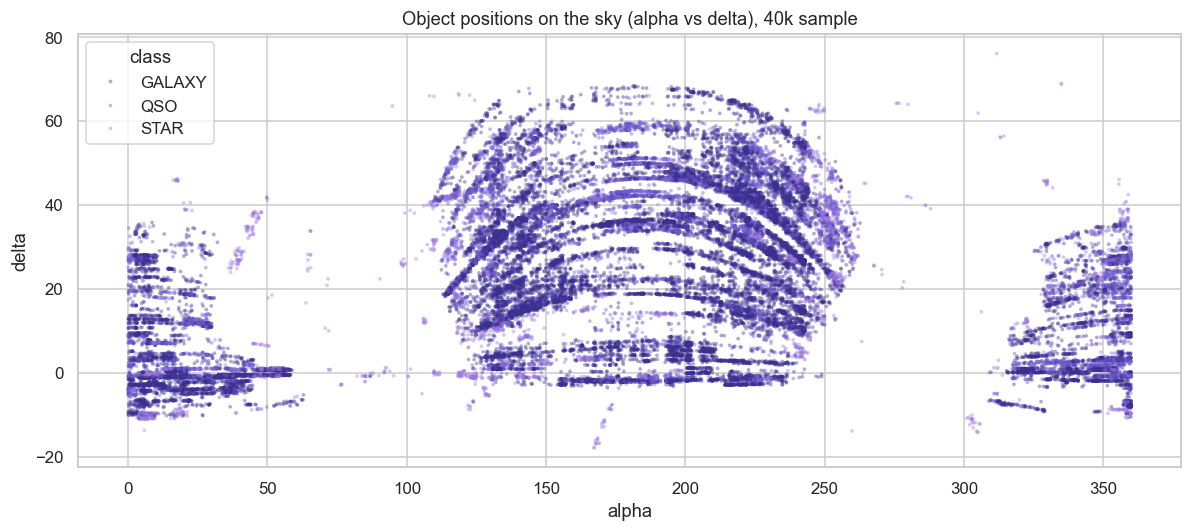

In [19]:
samp = train.sample(40000, random_state=42)
plt.figure(figsize=(11, 5))
sns.scatterplot(data=samp, x='alpha', y='delta', hue=TARGET, hue_order=CLASSES,
                palette=CLASS_PALETTE, s=6, alpha=0.4, linewidth=0)
plt.title('Object positions on the sky (alpha vs delta), 40k sample')
plt.tight_layout(); plt.show()

**Observations.** Classes are well mixed across the sky with no obvious spatial clustering by class. The `alpha`/`delta` coordinates therefore carry little direct class signal and are unlikely to be strong predictors on their own.

## 8. train vs test comparison (drift)
The dataset is synthetic — let's confirm that feature distributions are consistent between train and test.

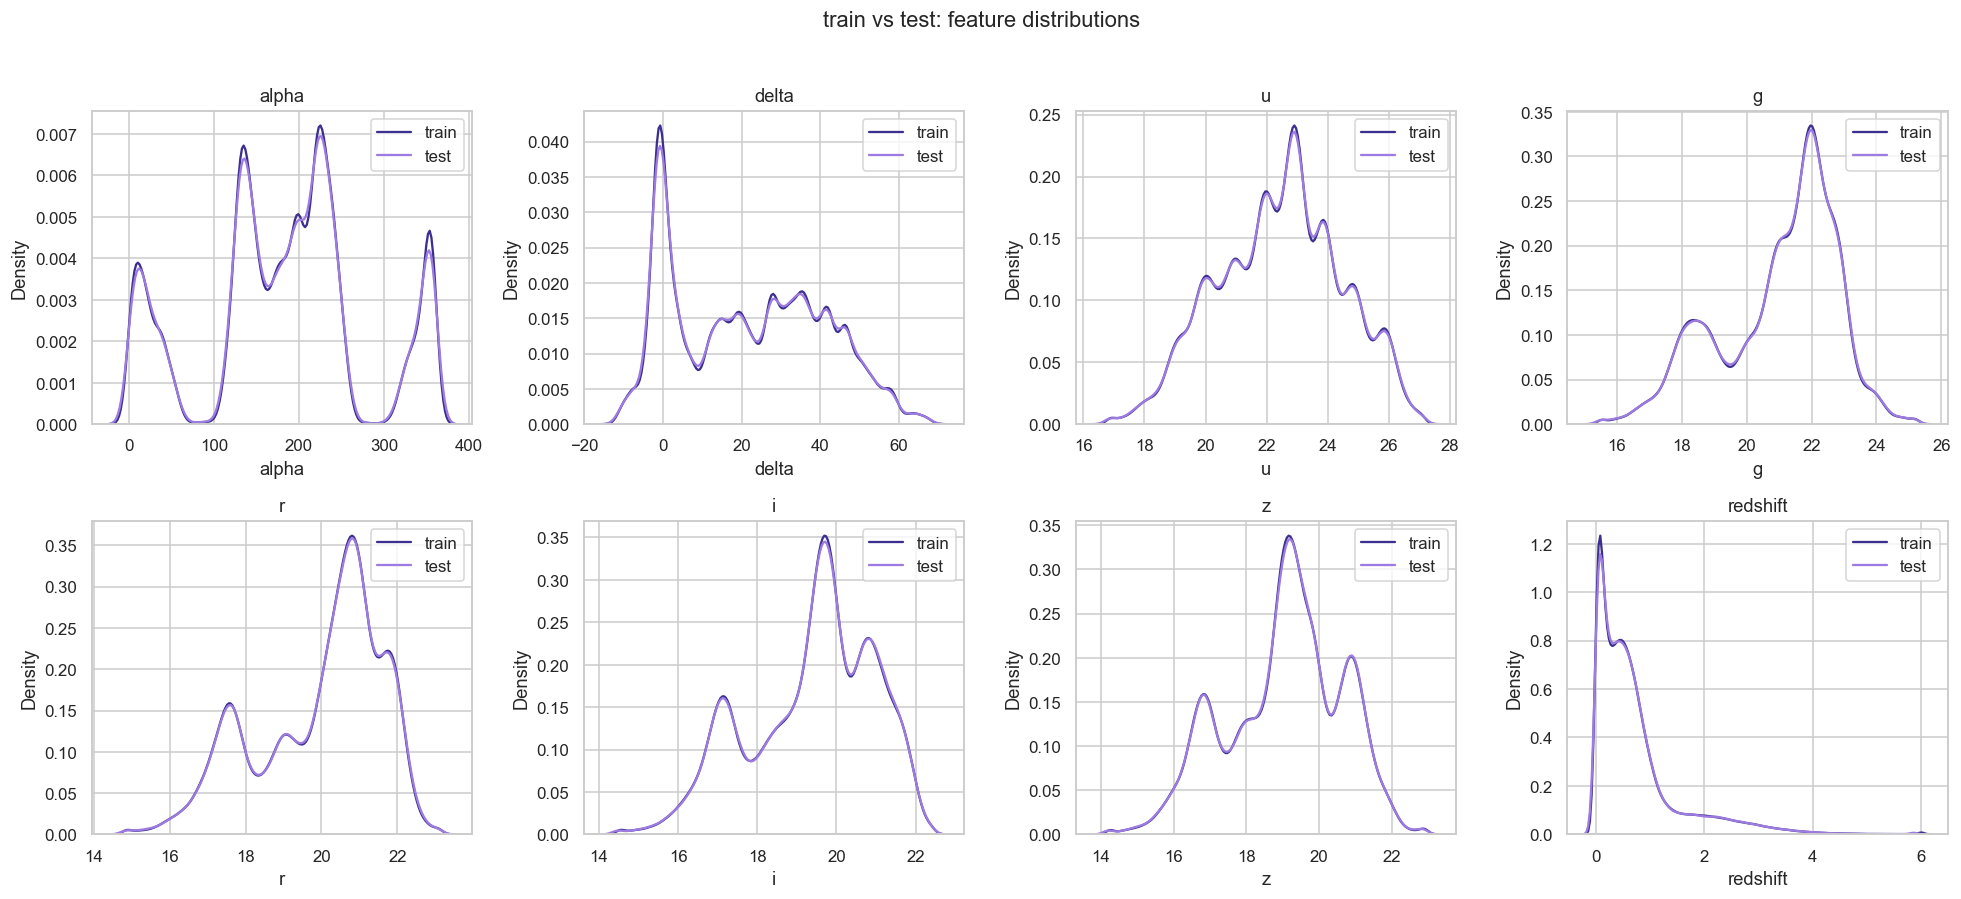

In [20]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.ravel(), num_cols):
    sns.kdeplot(train[col].clip(train[col].quantile(.001), train[col].quantile(.999)),
                label='train', ax=ax, color='#3B2F8F')
    sns.kdeplot(test[col].clip(test[col].quantile(.001), test[col].quantile(.999)),
                label='test', ax=ax, color='#9D7BE0')
    ax.set_title(col); ax.legend()
plt.suptitle('train vs test: feature distributions', y=1.02)
plt.tight_layout(); plt.show()

**Observations.** The train and test distributions overlap almost perfectly for every numeric feature — no meaningful covariate shift. A model validated on train CV should generalize reliably to the test set without drift-correction tricks.

### Adversarial validation (numeric drift check)
The KDE overlays above are eyeballed. Quantify drift with a single number: train a classifier to distinguish train from test rows. An ROC-AUC near 0.5 means the two splits are indistinguishable (no covariate shift).

In [ ]:
import lightgbm as lgb
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_auc_score

# Adversarial validation: can a model tell train from test? AUC ~0.5 means no drift.
# Keep cv at n_jobs=1 because LightGBM already uses all cores (avoid CPU oversubscription).
adv_X = pd.concat([train[num_cols], test[num_cols]], ignore_index=True)
adv_y = np.r_[np.zeros(len(train)), np.ones(len(test))]
adv_p = cross_val_predict(
    lgb.LGBMClassifier(n_estimators=200, learning_rate=0.05, num_leaves=63,
                       random_state=42, n_jobs=-1, verbose=-1),
    adv_X, adv_y, cv=3, method='predict_proba', n_jobs=1)[:, 1]
print('Adversarial validation AUC (train vs test):', round(roc_auc_score(adv_y, adv_p), 4))
print('Rule of thumb: ~0.5 = no covariate shift | >0.6 = drift worth investigating')

**Observations.** Adversarial AUC = **0.4994** — essentially random, so a model literally cannot tell train from test. This turns the eyeballed "distributions overlap" claim into a hard number: there is **no covariate shift**, and CV scores should track the leaderboard closely. No adversarial-validation reweighting or drift correction is needed.

## 9. Preprocessing and feature engineering
- `id` is not used as a feature.
- Build color indices from the photometry (physically meaningful SDSS features).
- Encode categorical features (ordered codes; for gradient boosting they can be passed as `category`).
- Encode the target into integer labels.

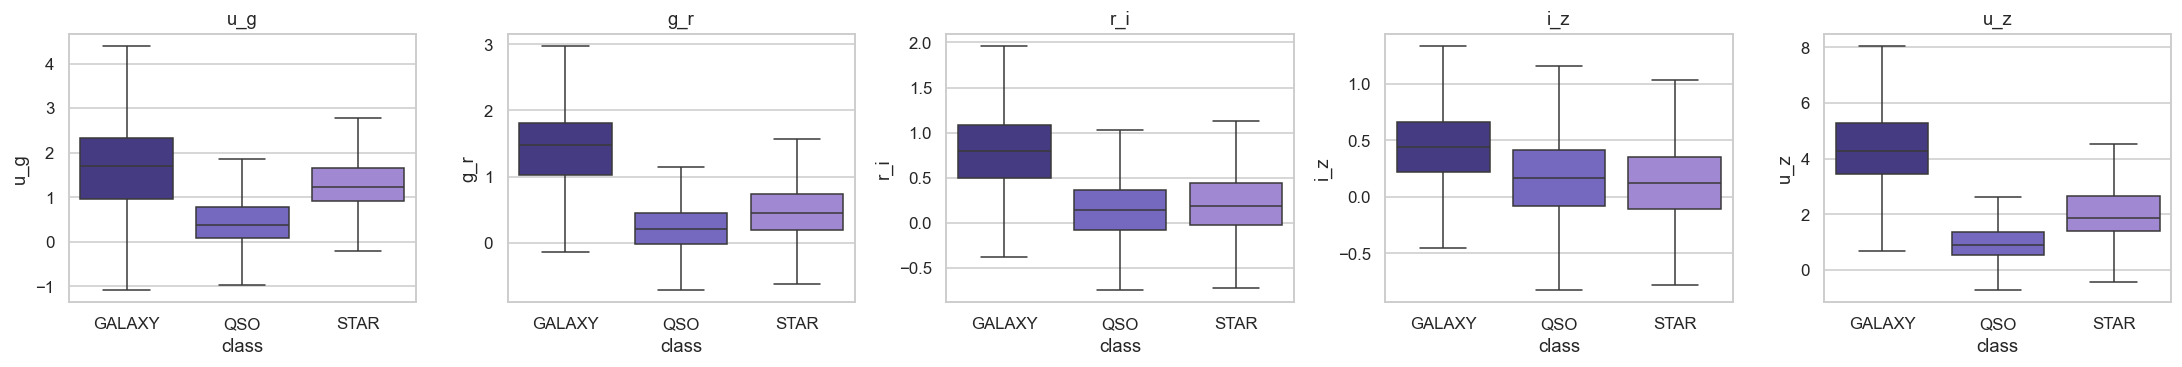

In [22]:
def add_features(df):
    df = df.copy()
    df['u_g'] = df['u'] - df['g']
    df['g_r'] = df['g'] - df['r']
    df['r_i'] = df['r'] - df['i']
    df['i_z'] = df['i'] - df['z']
    df['u_z'] = df['u'] - df['z']
    return df

train_fe = add_features(train)
test_fe = add_features(test)
color_cols = ['u_g', 'g_r', 'r_i', 'i_z', 'u_z']

fig, axes = plt.subplots(1, 5, figsize=(20, 3.5))
for ax, col in zip(axes, color_cols):
    sns.boxplot(data=train_fe, x=TARGET, y=col, order=CLASSES, ax=ax, showfliers=False,
                hue=TARGET, legend=False,
                palette=[CLASS_PALETTE[c] for c in CLASSES])
    ax.set_title(col)
plt.tight_layout(); plt.show()

**Observations.** The color indices show clearer class separation than the raw bands — `u_g` and `u_z` in particular shift noticeably between classes. This validates adding the colors as engineered features.

In [23]:
spectral_order = {'O/B': 0, 'A/F': 1, 'G/K': 2, 'M': 3}
pop_map = {'Blue_Cloud': 0, 'Red_Sequence': 1}

for df in (train_fe, test_fe):
    df['spectral_type_code'] = df['spectral_type'].map(spectral_order)
    df['galaxy_population_code'] = df['galaxy_population'].map(pop_map)

class_to_int = {c: i for i, c in enumerate(CLASSES)}
int_to_class = {i: c for c, i in class_to_int.items()}
train_fe['target'] = train_fe[TARGET].map(class_to_int)

feature_cols = num_cols + color_cols + ['spectral_type_code', 'galaxy_population_code']
print('Final features (%d):' % len(feature_cols))
print(feature_cols)
print('\nNull check after encoding:',
      train_fe[feature_cols].isnull().sum().sum(), test_fe[feature_cols].isnull().sum().sum())

Final features (15):
['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift', 'u_g', 'g_r', 'r_i', 'i_z', 'u_z', 'spectral_type_code', 'galaxy_population_code']

Null check after encoding: 0 0


**Observations.** 15 final features (8 numeric + 5 colors + 2 encoded categoricals) with zero nulls in both train and test after encoding. The ordinal `spectral_type` mapping (hot → cool) preserves a physically meaningful ordering. The feature matrix is model-ready.

## 10. Feature importance & mutual information
Before persisting, sanity-check the engineered feature set: which features actually carry class signal? We compare two complementary views — **mutual information** (model-free dependence with the target) and **LightGBM gain** (importance inside a fast tree model) — both normalized to [0, 1].

/tmp/claude-501/ipykernel_73564/492480803.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(frac=MI_SAMPLE / len(X_imp), random_state=42))


Mutual information computed on 50,000 stratified rows


,mutual_info,lgb_gain,mean_score
redshift,1.000,0.516,0.758
i_z,0.155,1.000,0.577
u_z,0.750,0.263,0.506
z,0.416,0.472,0.444
g_r,0.623,0.252,0.438
delta,0.220,0.655,0.438
r_i,0.423,0.361,0.392
i,0.306,0.476,0.391
u,0.348,0.401,0.374
g,0.343,0.311,0.327


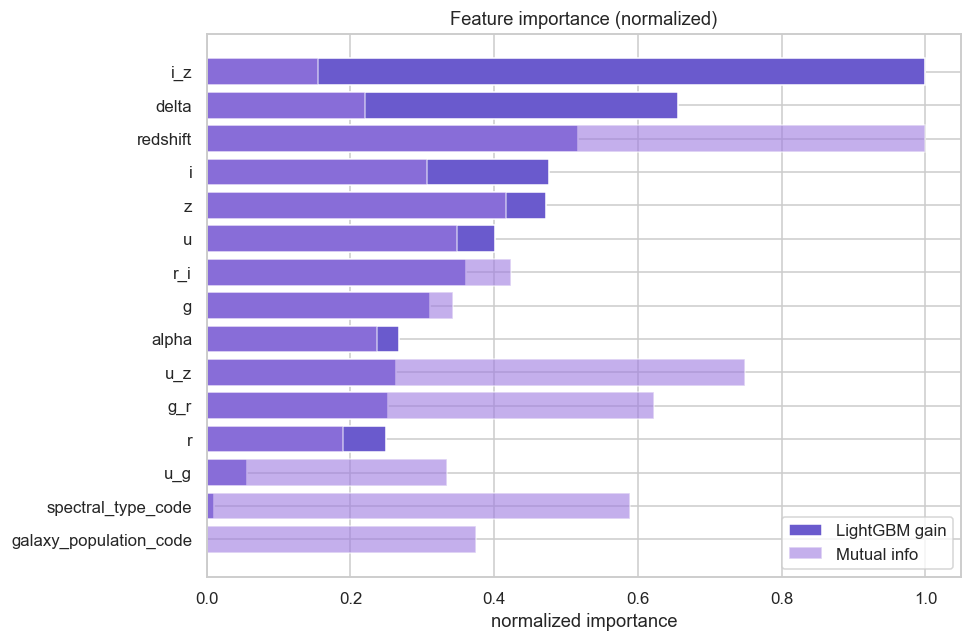

In [24]:
from sklearn.feature_selection import mutual_info_classif
import lightgbm as lgb

X_imp = train_fe[feature_cols]
y_imp = train_fe['target']
discrete = [X_imp.columns.get_loc(c) for c in ['spectral_type_code', 'galaxy_population_code']]

# Mutual information uses a KNN estimator that scales badly (~hour+ on full 577k on Kaggle).
# A stratified 50k subsample gives the same ranking in seconds.
MI_SAMPLE = 50_000
if len(X_imp) > MI_SAMPLE:
    mi_idx = (X_imp.assign(_y=y_imp)
              .groupby('_y', group_keys=False)
              .apply(lambda g: g.sample(frac=MI_SAMPLE / len(X_imp), random_state=42))
              .index)
else:
    mi_idx = X_imp.index
mi = mutual_info_classif(X_imp.loc[mi_idx], y_imp.loc[mi_idx],
                         discrete_features=discrete, random_state=42)
print(f'Mutual information computed on {len(mi_idx):,} stratified rows')

quick = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=63,
                           random_state=42, n_jobs=-1, verbose=-1)
quick.fit(X_imp, y_imp)
gain = quick.booster_.feature_importance(importance_type='gain')

imp = pd.DataFrame({'mutual_info': mi / mi.max(),
                    'lgb_gain': gain / gain.max()}, index=feature_cols)
imp['mean_score'] = imp.mean(axis=1)
imp = imp.sort_values('mean_score', ascending=False)
display(styled(imp, caption='Feature importance — normalized MI vs LightGBM gain',
               gradient=True, axis=0))

order = imp.sort_values('lgb_gain')
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(order.index, order['lgb_gain'], color='#6A5ACD', label='LightGBM gain')
ax.barh(order.index, order['mutual_info'], color='#9D7BE0', alpha=0.6, label='Mutual info')
ax.set_xlabel('normalized importance'); ax.set_title('Feature importance (normalized)')
ax.legend(loc='lower right')
plt.tight_layout(); plt.show()

**Observations.** Both views agree on the signal hierarchy: **`redshift`** (and its transform) and the encoded **`spectral_type`** dominate, followed by the **color indices** (`u_g`, `u_z`, …), exactly as the per-class EDA predicted. The raw, mutually-correlated magnitudes and the sky coordinates **`alpha`/`delta`** land at the bottom — confirming they can be dropped or down-weighted with little loss. Mutual information and tree gain rarely disagree by much here, which is reassuring: the engineered feature set is well-aligned with the target and free of obvious dead weight.

## 11. Reference CV score & sanity baselines
Close the EDA with a single number to beat. A fast LightGBM on the 15 engineered features, scored with honest 5-fold OOF `balanced_accuracy`, gives the modeling notebook a concrete reference. Two anchors put it in context: the majority-class baseline (lower bound) and a `redshift`-only depth-2 tree (how far the single strongest feature gets us).

In [ ]:
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import balanced_accuracy_score, classification_report

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# NOTE: avoid nested parallelism. LightGBM already uses all cores (n_jobs=-1),
# so keep cross_val_predict at n_jobs=1 (sequential folds). Doing both -1 oversubscribes
# the CPU (e.g. 5 folds x 4 cores on Kaggle) and runs many times slower.
ref_model = lgb.LGBMClassifier(n_estimators=400, learning_rate=0.05, num_leaves=63,
                               random_state=42, n_jobs=-1, verbose=-1)
oof = cross_val_predict(ref_model, X_imp, y_imp, cv=cv, n_jobs=1)
ref_ba = balanced_accuracy_score(y_imp, oof)

# Sanity anchors for context
majority_ba = balanced_accuracy_score(y_imp, np.full(len(y_imp), y_imp.mode()[0]))
rs_oof = cross_val_predict(DecisionTreeClassifier(max_depth=2, random_state=42),
                           X_imp[['redshift']], y_imp, cv=cv, n_jobs=1)
rs_ba = balanced_accuracy_score(y_imp, rs_oof)

print(f'Majority-class baseline   BA : {majority_ba:.4f}')
print(f'redshift-only (depth-2)   BA : {rs_ba:.4f}')
print(f'LightGBM (15 features)    BA : {ref_ba:.4f}  <- reference to beat')
print()
print(classification_report(y_imp, oof, target_names=CLASSES, digits=4))

**Observations.** The reference ladder: majority-class **0.3333** → `redshift`-only depth-2 tree **0.8232** → LightGBM on 15 features **0.9550** (honest 5-fold OOF). A single feature already gets ~82% of the way, confirming `redshift` as the backbone; the engineered set lifts it another ~13 points. Per-class recall: GALAXY 0.9770, QSO 0.9628, **STAR 0.9252** — STAR remains the weakest class and the lever for balanced accuracy. **0.9550 is the number the modeling notebook must beat.**

## 12. Persisting the feature set
Save the engineered `train`/`test` matrices so the downstream modeling notebook can load them directly without repeating preprocessing.

In [26]:
OUT_DIR.mkdir(parents=True, exist_ok=True)

train_fe[[ID] + feature_cols + ['target', TARGET]].to_parquet(OUT_DIR / 'train_fe.parquet', index=False)
test_fe[[ID] + feature_cols].to_parquet(OUT_DIR / 'test_fe.parquet', index=False)

print('Saved to', OUT_DIR.resolve())
print('train_fe:', train_fe[[ID] + feature_cols + ['target']].shape, '| test_fe:', test_fe[[ID] + feature_cols].shape)

Saved to /Users/flexonafft/MLKaggleTasks/competitions/predicting-stellar-class/data_processed
train_fe: (577347, 17) | test_fe: (247435, 16)


**Observations.** The engineered feature set is persisted to `OUT_DIR` (`/kaggle/working` on Kaggle, a local folder otherwise) as `train_fe.parquet` (features + `target` + `class`) and `test_fe.parquet` (features only). Modeling and the actual `submission.csv` are intentionally left to a separate notebook — this one stays a pure EDA + feature-prep step.

## EDA conclusions

**Data quality.** The data is clean and model-ready: zero missing values (except the target in test), no duplicate `id`, no fully duplicated rows, and identical feature schemas across train/test. Negative `delta` (~104k rows) and negative `redshift` (~9k rows) are physically valid and should be kept as-is.

**Target.** Strongly imbalanced — GALAXY 65.4% / QSO 20.3% / STAR 14.3%. Since the metric is **balanced accuracy** (mean per-class recall), the minority **STAR** class dominates the score: a model that is excellent on GALAXY/QSO but mediocre on STAR will score poorly.

**Signal structure.** Almost all class signal is concentrated in two features:
- **`redshift`** — the single strongest separator. Class means: STAR ≈ 0.07, GALAXY ≈ 0.51, QSO ≈ 1.88. STAR clusters tightly near zero, QSO sits high, GALAXY in between.
- **`spectral_type`** — near-deterministic for some levels: `M → 95% GALAXY`, `O/B → 71% QSO`, `A/F → 50% QSO`, `G/K → 57% GALAXY`.

**Weaker signal.** Raw `u, g, r, i, z` magnitudes are heavily mutually correlated and overlap across classes; the derived **color indices** (`u_g`, `u_z`, …) separate classes better. Sky coordinates `alpha`/`delta` carry essentially no class signal.

**No drift.** train and test distributions overlap almost perfectly across every numeric feature, so CV scores should track the leaderboard closely — no adversarial-validation / drift correction needed.

## Key findings & hypotheses

A few data-driven takeaways that should shape the modeling strategy:

- **The score battle is the STAR class.** With shares 65/20/14, balanced accuracy is bottlenecked by STAR. STAR is low-redshift but **not a tight spike at zero** (median ≈ 0.057, q99 ≈ 0.24) — its moderate tail **overlaps the low-redshift end of GALAXY** (GALAXY q01 ≈ 0.005). This `redshift` 0.01–0.25 band is where most STAR↔GALAXY confusion lives and deserves dedicated features.
- **High-redshift "stars" are real but rare.** STAR `redshift` reaches ≈ **5.4**, which is physically impossible for a star — but only **12** STAR rows exceed 0.5. So this is a genuine anomaly worth an explicit flag, yet too small to move the score much on its own; the moderate-overlap band above matters far more.
- **`spectral_type` is almost a rule-based classifier.** `M → 95% GALAXY` and `O/B → 71% QSO` mean a model can lean heavily on it; combined with `redshift` it should resolve most of the easy cases.
- **Clean inputs, no sentinels.** No `-9999`-style placeholders and no non-physical magnitudes in either split — so any sentinels that appear later would come from external data and must be filtered before merging.
- **Redundant photometry.** The five bands are near-collinear, so their raw values add little beyond the colors — dimensionality can be trimmed with no loss.

## Recommendations — feature engineering

- **Keep the color indices** — they already separate classes better than raw magnitudes. Consider extending to **all pairwise colors** (`u-r`, `g-i`, `r-z`, …), then prune by importance.
- **Tame `redshift` skew** — it spans 0–7 with a heavy right tail. Add `log1p(redshift)` and/or coarse redshift **bins**; tree models won't need it but it helps linear models / NNs and makes interactions cleaner.
- **Anomaly flags** — engineer `is_neg_redshift` and `is_star_like_z` (`redshift` close to 0). The high-redshift STAR tail (max ≈ 5.4, physically impossible for a star) is a prime suspect for misclassification — an explicit flag may help the model isolate it.
- **Interactions** — `redshift × spectral_type` is the most promising, since both are top signals and their combination is near-deterministic for several cells of the crosstab.
- **Target / categorical encoding** — `spectral_type` is so predictive that **target encoding** (done inside CV folds to avoid leakage) or CatBoost's native categorical handling is likely to beat the plain ordinal code.
- **Drop weak features** — `alpha`/`delta` show no class signal; keep them only if they help OOF, otherwise drop to reduce noise.

## Recommendations — modeling & validation

- **Model family.** Prefer gradient boosting (**LightGBM / XGBoost / CatBoost**) over ExtraTrees — stronger on tabular data and faster on 577k rows. **CatBoost** is attractive because it handles `spectral_type` / `galaxy_population` natively as categoricals.
- **Validation.** `StratifiedKFold` (5 folds) to preserve the class ratio, and score with `balanced_accuracy_score`. There is no drift, so OOF should track the leaderboard well.
- **Imbalance handling.** Because the metric rewards per-class recall, use `class_weight='balanced'` / `sample_weight`, or boosting's `is_unbalance` / `scale_pos_weight` analogues. Do **not** simply optimize plain accuracy.
- **Focus on STAR.** STAR is the expected bottleneck. Track the per-class recall and the STAR row of the confusion matrix every iteration — that single number drives balanced accuracy more than overall accuracy does.
- **Calibration / thresholds.** For balanced accuracy, tuning per-class decision thresholds on OOF probabilities can beat the default `argmax`.

## Recommendations — pushing the score further

- **External / original data.** Playground S6E6 is synthesized from the real *SDSS Stellar Classification* dataset. Concatenating the original data into the training set is a classic Playground-series tactic and frequently the single biggest score jump — worth trying early.
- **Pseudo-labeling.** Given the strong, low-noise signal, high-confidence test predictions can be folded back into training as pseudo-labels for a small extra boost.
- **Ensembling / blending.** Blend a GBDT (LightGBM/CatBoost) with a different model family (e.g. a small MLP on standardized colors + redshift). The decorrelated errors usually lift balanced accuracy.
- **Per-class threshold tuning.** Instead of `argmax`, optimize per-class decision thresholds on OOF predictions directly for balanced accuracy — cheap and targeted at the STAR/GALAXY boundary.

## Suggested roadmap

A pragmatic order of work for the modeling notebook, highest expected return first:

1. **Strong single model** — LightGBM/CatBoost on the 15 features, `StratifiedKFold(5)`, optimizing balanced accuracy with class weights. Establishes a real reference score.
2. **Attack STAR recall** — add the redshift-anomaly features, inspect the STAR row of the confusion matrix, tune class weights / decision thresholds specifically for STAR.
3. **Feature expansion** — full pairwise colors + target-encoded `spectral_type`; keep only what improves OOF.
4. **External SDSS data** — append the original dataset to train; often the single biggest jump in Playground series.
5. **Ensembling** — blend LightGBM + CatBoost + XGBoost (and optionally a NN) on OOF predictions.

> This notebook deliberately stops at clean EDA + a persisted feature set. All modeling, validation, and submission generation live in a separate notebook that loads `train_fe.parquet` / `test_fe.parquet`.